# Байесовский подход в анализе данных
## Задание 4

**Правила:**

* Дедлайны см. в боте. После дедлайна работы не принимаются кроме случаев наличия уважительной причины.
* Прислать нужно **ноутбук в формате `ipynb`**.
* Следите за размером файлов. **Бот не может принимать файлы весом более 20 Мб.** Если файл получается больше, заранее разделите его на несколько.
* Выполнять задание необходимо полностью самостоятельно. **При обнаружении списывания все участники списывания будут сдавать устный зачет.**
* Решения, размещенные на каких-либо интернет-ресурсах, не принимаются. Кроме того, публикация решения в открытом доступе может быть приравнена к предоставлении возможности списать.
* Для выполнения задания используйте этот ноутбук в качестве основы, ничего не удаляя из него. Можно добавлять необходимое количество ячеек.
* Комментарии к решению пишите в markdown-ячейках.
* Выполнение задания (ход решения, выводы и пр.) должно быть осуществлено на русском языке.
* Решение проверяется системой ИИ-проверки <a href="https://thetahat.ru/"><img src="https://miptstats.github.io/theta_grader_small.png" style="display: inline; vertical-align: middle;"></a> **ThetaGrader**. Результат проверки валидируется и исправляется человеком, после чего комментарии отправляются студентам.
* Если код будет не понятен проверяющему, оценка может быть снижена.
* Никакой код из данного задания при проверке запускаться не будет. *Если код студента не выполнен, недописан и т.д., то он не оценивается.*
* В каждой задаче не забывайте делать **пояснения и выводы**.


**Правила оформления теоретических задач:**

* Решения необходимо прислать одним из следующих способов:
  * фотографией в правильной ориентации, где все четко видно, а почерк разборчив,
    * вставив ее в ноутбук посредством `Edit -> Insert Image` (<font color="red">фото, вставленные ссылкой, или отдельные файлы-картинки/pdf рядом с ноутбуком, не принимаются</font>);
  * в виде $\LaTeX$ в markdown-ячейках.
* Решения не проверяются, если какое-то требование не выполнено. Особенно внимательно все проверьте в случае вставки фото в ноутбук. <font color="red"><b>Неправильно вставленные фотографии могут не передаться при отправке.</b></font> Для проверки попробуйте переместить `ipynb` в другую папку и открыть его там.
* В решениях поясняйте, чем вы пользуетесь, хотя бы кратко. Например, если пользуетесь независимостью, то достаточно подписи вида "*X и Y незав.*"
* Решение, в котором есть только ответ, и отсутствуют вычисления, оценивается в 0 баллов.

**Баллы за задание:**

* Задача 1 &mdash; 45 баллов;
* Задача 2 &mdash; 90 баллов;
* Задача 3 &mdash; 20 баллов;
* Задача 4 &mdash; 90 баллов.


---
### Задача 1.

Распишите итерационную процедуру EM-алгоритма и значение ELBO для метода Дэвида-Скина.

Напомним, функция неполного правдоподобия в данной модели имеет вид
$$p_{\pi,p}(N, Y) = \prod_{i\in I} \overbrace{\prod_{k \in K} \overbrace{\left( \overbrace{\rho_k}^{\stackrel{\text{\Large \textcolor{green}{вер-ть выбора}}}{\text{\textcolor{green}{этого класса}}}} \prod_{u\in U} \overbrace{\prod_{\ell \in K} \overbrace{\left( \pi_{k\ell}^u \right)^{n_{i\ell}^u} }^{\stackrel{\text{\large \textcolor{green}{$n_{i\ell}^u$ \Large раз поставлена}}}{\text{\textcolor{green}{метка $\ell$}}}}}^{\text{\textcolor{green}{фиксируем пользователя $u$}}} \right)^{\underbrace{Y_{ik}}_{\stackrel{\text{\large \textcolor{green}{выбор}}}{\text{\large \textcolor{green}{класса}}}}}}^{\text{\textcolor{green}{фиксируем для него истинный класс $k$}}}}^{\text{\textcolor{green}{рассматриваем объект $i$}}} \longrightarrow \max_{\pi, \rho}$$

где 
* $N = {n_{i\ell}^u}$ &mdash; наблюдаемые данные, $n_{i\ell}^u$ &mdash; количество раз, при которых разметчик $u \in U$ поставил класс $\ell \in K$ объекту $i \in I$;
* $Y_{ik} = I\{\text{объект } i \text{ класса } k\}$ &mdash; латентные величины;
* $\pi_{k\ell}^u$ &mdash; вероятность того, что разметчик $u$ поставил класс $\ell$ вместо правильного класса $k$, параметр модели;
* $\rho_k$ &mdash; вероятность класса $k$, параметр модели.

$\square$
## СМ. ПДФ
$\blacksquare$

In [344]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
import scipy.stats as sps

import numba
from numba import jit

---
### Задача 2.

**1.** Реализуйте следующие методы агрегации результатов разметки в краудсорсинге:
* голосование по большинству;
* метод Дэвида-Скина.

Результатом работы каждого метода должна быть таблица вероятностей классов для каждого объекта датасета. Итоговая метка получается выбором класса с наибольшей оценкой вероятности. 

*Замечания.*
* Метод голосования по большинству можно реализовать с помощью одной агрегирующей функцией `pandas.crosstab`.
* Метод Дэвида-Скина основывается на EM-алгоритме. При реализации должны быть учтены его особенности.
* При реализации используйте пример реализации GLAD, разобранный на занятии. В частности, используйте вспомогательные функции, ускорение с помощью `numba`.
* Постарайтесь написать красивый и понятный код, желательно &mdash; в виде классов.

In [345]:
@jit(nopython=True)
def log_sigmoid(x):
    if x >= 0:
        return -np.log1p(np.exp(-x))
    else:
        return x - np.log1p(np.exp(x))

@jit(nopython=True)
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

@jit(nopython=True)
def log_one_minus_sigmoid(x):
    if x >= 0:
        return -x - np.log1p(np.exp(-x))
    else:
        return -np.log1p(np.exp(x))

@jit(nopython=True)
def logsumexp(a):
    a_max = np.max(a)
    if not np.isfinite(a_max):
        return a_max
    s = np.sum(np.exp(a - a_max))
    return np.log(s) + a_max

In [346]:
class DavidSkin:
    def __init__(self, df, worker_col="worker_id", item_col="item_id", label_col="label"):

        worker_ids = df[worker_col].values
        item_ids = df[item_col].values
        labels = df[label_col].values
        self.num_classes = len(np.unique(labels))

        self.unique_workers = np.unique(worker_ids)
        self.unique_items = np.unique(item_ids)
        self.num_workers = len(self.unique_workers)
        self.num_items = len(self.unique_items)

        self.worker2ind = {w: i for i, w in enumerate(self.unique_workers)}
        self.item2ind = {t: i for i, t in enumerate(self.unique_items)}

        self.observations = np.empty((len(worker_ids), 3), dtype=np.int32)
        for idx, (w, t, l) in enumerate(zip(worker_ids, item_ids, labels)):
            self.observations[idx, 0] = self.worker2ind[w]
            self.observations[idx, 1] = self.item2ind[t]
            self.observations[idx, 2] = int(l)

        self.pi = 0.9 / self.num_classes + 0.1 * np.random.rand(self.num_workers, self.num_classes, self.num_classes)
        self.pi /= self.pi.sum(axis=2, keepdims=True)

        self.rhos = np.full(self.num_classes, 1.0 / self.num_classes)

        self.gamma = np.random.dirichlet(alpha=np.ones(self.num_classes), size=self.num_items)

    @staticmethod
    @jit(nopython=True)
    def E_step_sparse(observations, log_pi, log_rhos, gamma, num_items, num_classes):
        log_likelihood = np.empty((num_items, num_classes), dtype=np.float64)
        for i in range(num_items):
            for k in range(num_classes):
                log_likelihood[i, k] = log_rhos[k]

        for obs_idx in range(observations.shape[0]):
            w, i, l = observations[obs_idx, 0], observations[obs_idx, 1], observations[obs_idx, 2]
            for k in range(num_classes):
                log_likelihood[i, k] += log_pi[w, k, l]

        for i in range(num_items):
            max_log = log_likelihood[i, 0]
            for k in range(1, num_classes):
                if log_likelihood[i, k] > max_log:
                    max_log = log_likelihood[i, k]
            exp_sum = 0.0
            for k in range(num_classes):
                val = np.exp(log_likelihood[i, k] - max_log)
                gamma[i, k] = val
                exp_sum += val
            for k in range(num_classes):
                gamma[i, k] /= exp_sum

    @staticmethod
    @jit(nopython=True)
    def M_step_sparse(observations, gamma, pi, rhos, num_classes, alpha):
        num_items = gamma.shape[0]
        num_workers = pi.shape[0]

        for k in range(num_classes):
            total = 0.0
            for i in range(num_items):
                total += gamma[i, k]
            rhos[k] = total / num_items

        counts = np.zeros((num_workers, num_classes, num_classes), dtype=np.float64)
        totals = np.zeros((num_workers, num_classes), dtype=np.float64)

        for obs_idx in range(observations.shape[0]):
            w, i, l = observations[obs_idx, 0], observations[obs_idx, 1], observations[obs_idx, 2]
            for k in range(num_classes):
                weight = gamma[i, k]
                counts[w, k, l] += weight
                totals[w, k] += weight

        for w in range(num_workers):
            for k in range(num_classes):
                denom = totals[w, k] + alpha * num_classes
                for l in range(num_classes):
                    pi[w, k, l] = (counts[w, k, l] + alpha) / denom

    @staticmethod
    @jit(nopython=True)
    def ELBO_sparse(observations, gamma, pi, rhos, num_items, num_classes):
        eps = 1e-12
        elbo = 0.0

        for i in range(num_items):
            for k in range(num_classes):
                g = gamma[i, k]
                if g > 0:
                    elbo += g * np.log(rhos[k] + eps)

        for obs_idx in range(observations.shape[0]):
            w, i, l = observations[obs_idx, 0], observations[obs_idx, 1], observations[obs_idx, 2]
            for k in range(num_classes):
                g = gamma[i, k]
                if g > 0:
                    elbo += g * np.log(pi[w, k, l] + eps)

        for i in range(num_items):
            for k in range(num_classes):
                g = gamma[i, k]
                if g > 0:
                    elbo -= g * np.log(g + eps)

        return elbo

    def fit(self, max_iter=100, tol=1e-4, alpha=1.0, verbose=True):
        elbo_values = []
        eps = 1e-12

        log_pi = np.log(self.pi + eps)
        log_rhos = np.log(self.rhos + eps)

        iterator = tqdm(range(max_iter), desc="EM Iterations") if verbose else range(max_iter)

        for iteration in iterator:
            self.E_step_sparse(
                self.observations, log_pi, log_rhos, self.gamma,
                self.num_items, self.num_classes
            )

            elbo = self.ELBO_sparse(
                self.observations, self.gamma, self.pi, self.rhos,
                self.num_items, self.num_classes
            )
            elbo_values.append(elbo)

            if verbose:
                print(f"Iteration {iteration}, ELBO = {elbo:.6f}")

            # Проверка сходимости (начиная со 2-й итерации)
            if iteration > 0 and abs(elbo - elbo_values[-2]) < tol:
                if verbose:
                    print("Converged.")
                break

            self.M_step_sparse(
                self.observations, self.gamma, self.pi, self.rhos,
                self.num_classes, alpha
            )

            log_pi = np.log(self.pi + eps)
            log_rhos = np.log(self.rhos + eps)

        return elbo_values

    def predict(self):
        predicted_labels = np.argmax(self.gamma, axis=1)
        return pd.DataFrame({
            "item_id": self.unique_items,
            "predicted_label": predicted_labels
        })

In [347]:
# class DavidSkin:
#     def __init__(self, df, num_classes, worker_col="worker_id", item_col="item_id", label_col="label"):
#         self.num_classes = num_classes

#         self.worker_ids = df[worker_col].values
#         self.item_ids = df[item_col].values
#         self.labels = df[label_col].values

#         self.unique_workers = np.unique(self.worker_ids)
#         self.unique_items = np.unique(self.item_ids)
#         self.num_workers = len(self.unique_workers)
#         self.num_items = len(self.unique_items)

#         self.worker2ind = {w: i for i, w in enumerate(self.unique_workers)}
#         self.item2ind = {t: i for i, t in enumerate(self.unique_items)}

#         self.n = np.zeros((self.num_workers, self.num_items, num_classes), dtype=np.float64)
#         for w, t, l in zip(self.worker_ids, self.item_ids, self.labels):
#             iw = self.worker2ind[w]
#             it = self.item2ind[t]
#             self.n[iw, it, l] += 1

#         self.pi = np.ones((self.num_workers, num_classes, num_classes), dtype=np.float64) / num_classes
#         self.rhos = np.ones(num_classes, dtype=np.float64) / num_classes
#         self.gamma = np.zeros((self.num_items, num_classes), dtype=np.float64)

#     @staticmethod
#     @numba.jit(nopython=True, parallel=True)
#     def E_step_numba(n, pi, rhos, gamma):
#         num_workers, num_items, num_classes = n.shape
#         for i in range(num_items):
#             logs = np.zeros(num_classes)
#             for k in range(num_classes):
#                 log_rho_k = np.log(rhos[k])
#                 tmp_sum = 0.0
#                 for w in range(num_workers):
#                     for l in range(num_classes):
#                         if pi[w, k, l] > 0:
#                             tmp_sum += n[w, i, l] * np.log(pi[w, k, l])
#                 logs[k] = log_rho_k + tmp_sum
#             log_denom = logsumexp(logs)
#             for k in range(num_classes):
#                 gamma[i, k] = np.exp(logs[k] - log_denom)

#     @staticmethod
#     @numba.jit(nopython=True, parallel=True)
#     def M_step_numba(n, gamma, pi, rhos):
#         num_workers, num_items, num_classes = n.shape
#         # update rhos
#         for k in range(num_classes):
#             s = 0.0
#             for i in range(num_items):
#                 s += gamma[i, k]
#             rhos[k] = s / num_items
#         # update pi
#         for w in range(num_workers):
#             for k in range(num_classes):
#                 weighted_counts = np.zeros(num_classes, dtype=np.float64)
#                 denom = 0.0
#                 for i in range(num_items):
#                     for l in range(num_classes):
#                         weighted_counts[l] += gamma[i, k] * n[w, i, l]
#                         denom += gamma[i, k] * n[w, i, l]
#                 if denom > 0:
#                     for l in range(num_classes):
#                         pi[w, k, l] = weighted_counts[l] / denom

#     def E_step(self):
#         self.E_step_numba(self.n, self.pi, self.rhos, self.gamma)

#     def M_step(self):
#         self.M_step_numba(self.n, self.gamma, self.pi, self.rhos)

#     @staticmethod
#     @numba.jit(nopython=True, parallel=True)
#     def ELBO_numba(n, gamma, pi, rhos):
#         num_workers, num_items, num_classes = n.shape
#         elbo = 0.0
#         for i in range(num_items):
#             for k in range(num_classes):
#                 if gamma[i, k] > 0:
#                     elbo += gamma[i, k] * np.log(rhos[k])
#                     for w in range(num_workers):
#                         for l in range(num_classes):
#                             if pi[w, k, l] > 0:
#                                 elbo += gamma[i, k] * n[w, i, l] * np.log(pi[w, k, l])
#                     elbo -= gamma[i, k] * np.log(gamma[i, k])
#         return elbo

#     def fit(self, max_iter=100, tol=1e-4):
#         elbo_values = []
#         for iteration in tqdm(range(max_iter), desc="EM Iterations"):
#             self.E_step()
#             self.M_step()
#             elbo = self.ELBO_numba(self.n, self.gamma, self.pi, self.rhos)
#             elbo_values.append(elbo)
#             print(f"Iteration {iteration}, ELBO = {elbo:.6f}")
#             if iteration > 0 and abs(elbo - elbo_values[-2]) < tol:
#                 break
#         return elbo_values

#     def predict(self):
#         """
#         Возвращает DataFrame с колонками:
#         - item_id
#         - predicted_label
#         """
#         predicted_labels = np.argmax(self.gamma, axis=1)
#         df_pred = pd.DataFrame({
#             "item_id": self.unique_items,
#             "predicted_label": predicted_labels
#         })
#         return df_pred

In [348]:
class MajorityVoting:
    def __init__(self, df, worker_col="worker_id", item_col="item_id", label_col="label"):
        self.df = df.copy()
        self.num_classes = len(np.unique(df[label_col].values))
        self.worker_col = worker_col
        self.item_col = item_col
        self.label_col = label_col

    def predict(self):
        ct = pd.crosstab(
            index=self.df[self.item_col],
            columns=self.df[self.label_col],
            dropna=False
        )
        
        for cls in range(self.num_classes):
            if cls not in ct.columns:
                ct[cls] = 0
        
        ct = ct.reindex(sorted(ct.columns), axis=1)
        
        predicted_labels = ct.idxmax(axis=1)
        
        result = predicted_labels.reset_index()
        result.columns = [self.item_col, "predicted_label"]
        result["predicted_label"] = result["predicted_label"].astype(int)
        
        return result

In [362]:
class GLAD:
    def __init__(self, df, worker_col="worker_id", item_col="item_id", label_col="label"):
        worker_ids = df[worker_col].values
        item_ids = df[item_col].values
        labels = df[label_col].values

        self.unique_workers = np.unique(worker_ids)
        self.unique_items = np.unique(item_ids)
        self.num_workers = len(self.unique_workers)
        self.num_items = len(self.unique_items)
        self.num_classes = len(np.unique(labels))

        self.worker2ind = {w: i for i, w in enumerate(self.unique_workers)}
        self.item2ind = {t: i for i, t in enumerate(self.unique_items)}

        # преобразуем в индексы
        self.users = np.array([self.worker2ind[w] for w in worker_ids], dtype=np.int32)
        self.objects = np.array([self.item2ind[t] for t in item_ids], dtype=np.int32)
        self.labels = np.array(labels, dtype=np.int32)

        # инициализация параметров
        self.log_pi, self.alpha, self.beta = self.initialize()
        self.log_gamma = np.zeros((self.num_items, self.num_classes))

    def initialize(self):
        log_pi = np.log(sps.dirichlet(np.ones(self.num_classes)).rvs()[0])
        alpha = sps.norm(loc=1).rvs(size=self.num_workers)
        beta = np.exp(sps.norm(loc=1).rvs(size=self.num_items))
        return log_pi, alpha, beta

    @staticmethod
    @jit(nopython=True)
    def E_step(users, objects, labels, alpha, beta, log_pi, objects_count, class_count):
        M = len(labels)
        log_gamma = np.zeros((objects_count, class_count)) + log_pi.reshape((1, -1))
        for m in range(M):
            u = users[m]
            i = objects[m]
            x = labels[m]
            neg_prob = log_one_minus_sigmoid(alpha[u] * beta[i]) - np.log(class_count - 1)
            for k in range(class_count):
                if x == k:
                    log_gamma[i, k] += log_sigmoid(alpha[u] * beta[i])
                else:
                    log_gamma[i, k] += neg_prob
        for i in range(objects_count):
            log_gamma[i] -= logsumexp(log_gamma[i])
        return log_gamma

    @staticmethod
    @jit(nopython=True)
    def M_step(users, objects, labels, alpha, beta, log_gamma, objects_count, class_count, lr=0.0001, n_iter=50):
        M = len(labels)
        log_pi = np.zeros(class_count)
        for k in range(class_count):
            log_pi[k] = logsumexp(log_gamma[:, k]) - np.log(objects_count)
        gamma = np.exp(log_gamma)
        for _ in range(n_iter):
            alpha_iter = alpha[:]
            beta_iter = beta[:]
            for m in range(M):
                u = users[m]
                i = objects[m]
                x = labels[m]
                sigma = sigmoid(alpha[u] * beta[i])
                for k in range(class_count):
                    alpha_iter[u] += lr * gamma[i, k] * beta[i] * (int(x == k) - sigma)
                    beta_iter[i] += lr * gamma[i, k] * alpha[u] * (int(x == k) - sigma)
            alpha = alpha_iter
            beta = beta_iter
        return alpha, beta, log_pi

    @staticmethod
    @jit(nopython=True)
    def elbo(users, objects, labels, alpha, beta, log_pi, log_gamma, objects_count, class_count):
        M = len(labels)
        gamma = np.exp(log_gamma)
        elbo_value = (gamma * log_pi.reshape((1, -1))).sum() - (gamma * log_gamma).sum()
        for m in range(M):
            u = users[m]
            i = objects[m]
            x = labels[m]
            neg_prob = log_one_minus_sigmoid(alpha[u] * beta[i]) - np.log(class_count - 1)
            for k in range(class_count):
                if x == k:
                    elbo_value += gamma[i, k] * log_sigmoid(alpha[u] * beta[i])
                else:
                    elbo_value += gamma[i, k] * neg_prob
        return elbo_value

    def fit(self, n_iter=50, n_init=5, lr=0.0001):
        best_elbo = -np.inf
        best_params = {}
        for init in tqdm(range(n_init), desc=f"GLAD n_init={n_init}"):
            self.log_pi, self.alpha, self.beta = self.initialize()
            for it in tqdm(range(n_iter), desc="EM Iterations"):
                self.log_gamma = self.E_step(
                    self.users, self.objects, self.labels, 
                    self.alpha, self.beta, self.log_pi, 
                    self.num_items, self.num_classes
                )
                self.alpha, self.beta, self.log_pi = self.M_step(
                    self.users, self.objects, self.labels, 
                    self.alpha, self.beta, self.log_gamma, 
                    self.num_items, self.num_classes,
                    lr=lr
                )
                current_elbo = self.elbo(
                    self.users, self.objects, self.labels, 
                    self.alpha, self.beta, self.log_pi, self.log_gamma, 
                    self.num_items, self.num_classes
                )
                print(f"Current ELBO: {current_elbo}")
            if current_elbo > best_elbo:
                best_elbo = current_elbo
                best_params = {
                    'gamma': np.exp(self.log_gamma),
                    'pi': np.exp(self.log_pi),
                    'alpha': self.alpha.copy(),
                    'beta': self.beta.copy(),
                    'elbo': best_elbo
                }
        self.gamma = best_params['gamma']
        self.pi = best_params['pi']
        self.alpha = best_params['alpha']
        self.beta = best_params['beta']
        self.best_elbo = best_params['elbo']
        return best_params

    def predict(self):
        predicted_labels = np.argmax(self.gamma, axis=1)
        return pd.DataFrame({
            "item_id": self.unique_items,
            "predicted_label": predicted_labels
        })

**2.** Примените эти два метода и метод GLAD с занятия к следующим <a href="https://toloka.ai/ru/datasets">открытым данным</a> Яндекс.Толоки:
* Toloka Aggregation Features;
* Toloka Aggregation Relevance 2;
* Toloka Aggregation Relevance 5.

Обратите внимание, что в последнем датасете 5 различных меток, причем некоторые объекты в датасете имеют не один, а несколько правильных ответов. Любой из таких ответов считается правильным.

Реализацию метода GLAD возьмите с занятия.

## Toloka Aggregation Relevance 2

In [379]:
toloka_relevance_2_crowd = pd.read_csv("toloka_relevance_2/crowd_labels.tsv", sep="\t", header=None, names=["worker_id", "item_id", "label"])
toloka_relevance_2_true = pd.read_csv("toloka_relevance_2/golden_labels.tsv", sep="\t", header=None, names=["item_id", "true_label"])

toloka_relevance_2_crowd["item_id"] = toloka_relevance_2_crowd["item_id"].astype(str)
toloka_relevance_2_true["item_id"] = toloka_relevance_2_true["item_id"].astype(str)

In [380]:
toloka_relevance_2_crowd = toloka_relevance_2_crowd[:100000]

In [381]:
toloka_relevance_2_crowd.head()

,worker_id,item_id,label
0,w851,t30685,1
1,w6991,t30008,0
2,w2596,t36316,0
3,w5507,t15145,1
4,w2982,t44785,1


In [382]:
toloka_relevance_2_crowd.shape

(100000, 3)

In [383]:
DavidSkin_model = DavidSkin(toloka_relevance_2_crowd)
GLAD_model = GLAD(toloka_relevance_2_crowd)
MajorityVoting_model = MajorityVoting(toloka_relevance_2_crowd)

In [384]:
DavidSkin_model.fit(max_iter=200, tol=1e-4);

EM Iterations:   0%|          | 0/200 [00:00<?, ?it/s]

Iteration 0, ELBO = -69354.184651
Iteration 1, ELBO = -60935.951975
Iteration 2, ELBO = -60933.893249
Iteration 3, ELBO = -60933.162315
Iteration 4, ELBO = -60932.406130
Iteration 5, ELBO = -60931.490894
Iteration 6, ELBO = -60930.328556
Iteration 7, ELBO = -60928.827658
Iteration 8, ELBO = -60926.876138
Iteration 9, ELBO = -60924.329704
Iteration 10, ELBO = -60921.000489
Iteration 11, ELBO = -60916.644570
Iteration 12, ELBO = -60910.948182
Iteration 13, ELBO = -60903.513329
Iteration 14, ELBO = -60893.844332
Iteration 15, ELBO = -60881.337929
Iteration 16, ELBO = -60865.280831
Iteration 17, ELBO = -60844.859864
Iteration 18, ELBO = -60819.190075
Iteration 19, ELBO = -60787.364591
Iteration 20, ELBO = -60748.526150
Iteration 21, ELBO = -60701.955232
Iteration 22, ELBO = -60647.165107
Iteration 23, ELBO = -60583.991389
Iteration 24, ELBO = -60512.663121
Iteration 25, ELBO = -60433.843530
Iteration 26, ELBO = -60348.630678
Iteration 27, ELBO = -60258.511259
Iteration 28, ELBO = -60165.26

In [392]:
GLAD_model.fit(n_init=10, lr=0.0001);

GLAD n_init=10:   0%|          | 0/10 [00:00<?, ?it/s]

EM Iterations:   0%|          | 0/50 [00:00<?, ?it/s]

Current ELBO: -91431.79958020168
Current ELBO: -86624.821521148
Current ELBO: -83158.96872721045
Current ELBO: -80519.62091247471
Current ELBO: -78472.44865432648
Current ELBO: -76829.17656930526
Current ELBO: -75496.396609946
Current ELBO: -74397.13850786068
Current ELBO: -73486.48703080142
Current ELBO: -72721.80389936182
Current ELBO: -72059.35137247006
Current ELBO: -71478.96950101749
Current ELBO: -70966.96585575255
Current ELBO: -70510.70059768257
Current ELBO: -70102.56430949864
Current ELBO: -69734.77753310931
Current ELBO: -69400.10771278046
Current ELBO: -69093.11725096444
Current ELBO: -68813.96055063816
Current ELBO: -68561.16365869787
Current ELBO: -68331.05751259638
Current ELBO: -68120.51330330117
Current ELBO: -67926.99748955756
Current ELBO: -67748.00228437813
Current ELBO: -67581.54293288913
Current ELBO: -67426.12445249212
Current ELBO: -67281.02660498412
Current ELBO: -67146.09443281297
Current ELBO: -67019.84996280813
Current ELBO: -66900.22753374053
Current ELBO: 

EM Iterations:   0%|          | 0/50 [00:00<?, ?it/s]

Current ELBO: -92506.48267828573
Current ELBO: -87083.57857123863
Current ELBO: -83551.34052437494
Current ELBO: -80949.9522572569
Current ELBO: -78906.12298855453
Current ELBO: -77257.63067726069
Current ELBO: -75896.73220626023
Current ELBO: -74744.20810157988
Current ELBO: -73755.71447015236
Current ELBO: -72913.35212507953
Current ELBO: -72198.09326934448
Current ELBO: -71587.79755436107
Current ELBO: -71051.77877110093
Current ELBO: -70575.53796107096
Current ELBO: -70147.44223471178
Current ELBO: -69758.96509317929
Current ELBO: -69405.70839708642
Current ELBO: -69083.95273276349
Current ELBO: -68790.44073082451
Current ELBO: -68522.48278804451
Current ELBO: -68277.01907844766
Current ELBO: -68052.24263448764
Current ELBO: -67846.95543342453
Current ELBO: -67659.02036956593
Current ELBO: -67486.37252512565
Current ELBO: -67326.80764285597
Current ELBO: -67177.90613369802
Current ELBO: -67038.74632275305
Current ELBO: -66909.00500965903
Current ELBO: -66787.70280414443
Current ELB

...

Current ELBO: -97735.30121490356
Current ELBO: -87593.26251874203
Current ELBO: -83724.00089099465
Current ELBO: -81148.15312784996
Current ELBO: -79124.01747691841
Current ELBO: -77450.00710645379
Current ELBO: -76051.4343288384
Current ELBO: -74883.11402373579
Current ELBO: -73884.15051635863
Current ELBO: -73019.46073209214
Current ELBO: -72274.42128927112
Current ELBO: -71629.70149151623
Current ELBO: -71072.50541254663
Current ELBO: -70593.70925170394
Current ELBO: -70175.73039762654
Current ELBO: -69803.31212661095
Current ELBO: -69468.11442634866
Current ELBO: -69165.04913480565
Current ELBO: -68889.71623520082
Current ELBO: -68638.12643338315
Current ELBO: -68407.584361051
Current ELBO: -68195.43402910889
Current ELBO: -67999.00941884032
Current ELBO: -67817.18926484179
Current ELBO: -67649.30649745242
Current ELBO: -67494.56916577501
Current ELBO: -67351.8168778029
Current ELBO: -67219.59261032236
Current ELBO: -67096.3661937929
Current ELBO: -66980.79291852449
Current ELBO: -

EM Iterations:   0%|          | 0/50 [00:00<?, ?it/s]

Current ELBO: -102903.70865926557
Current ELBO: -88107.8002503403
Current ELBO: -83367.29533019265
Current ELBO: -80575.3468059513
Current ELBO: -78541.56195439528
Current ELBO: -76910.76241781568
Current ELBO: -75559.13861429848
Current ELBO: -74427.54868656304
Current ELBO: -73492.3855469401
Current ELBO: -72700.3484946086
Current ELBO: -72016.17166268571
Current ELBO: -71422.37475888547
Current ELBO: -70906.71002320923
Current ELBO: -70455.97843270403
Current ELBO: -70055.31720077914
Current ELBO: -69702.08069271238
Current ELBO: -69389.18656978816
Current ELBO: -69108.08284948532
Current ELBO: -68852.47457305649
Current ELBO: -68617.80112588005
Current ELBO: -68400.75088221686
Current ELBO: -68198.94082007164
Current ELBO: -68010.56785303124
Current ELBO: -67834.4264270096
Current ELBO: -67669.63728211765
Current ELBO: -67515.14260860674
Current ELBO: -67370.76190403815
Current ELBO: -67236.49822137218
Current ELBO: -67111.46979171838
Current ELBO: -66994.7571157256
Current ELBO: -

EM Iterations:   0%|          | 0/50 [00:00<?, ?it/s]

Current ELBO: -96948.96086688591
Current ELBO: -86417.06636206979
Current ELBO: -82435.39482909162
Current ELBO: -80006.17080778746
Current ELBO: -78186.38451705597
Current ELBO: -76717.7231199455
Current ELBO: -75499.39201208396
Current ELBO: -74463.95161595853
Current ELBO: -73573.67404420582
Current ELBO: -72801.6111758176
Current ELBO: -72127.17120951504
Current ELBO: -71541.43459568723
Current ELBO: -71028.40078774742
Current ELBO: -70573.34527330393
Current ELBO: -70164.15782496783
Current ELBO: -69794.52659908427
Current ELBO: -69460.4095521497
Current ELBO: -69156.48701524132
Current ELBO: -68878.08952771481
Current ELBO: -68622.11324278484
Current ELBO: -68386.77399629662
Current ELBO: -68171.92912697926
Current ELBO: -67975.43344752016
Current ELBO: -67794.65037635074
Current ELBO: -67627.79083179418
Current ELBO: -67473.09363747941
Current ELBO: -67328.9751336482
Current ELBO: -67195.69415096179
Current ELBO: -67071.70503945452
Current ELBO: -66955.61573387333
Current ELBO: 

In [393]:
predicted_DavidSkin = DavidSkin_model.predict()
predicted_GLAD = GLAD_model.predict()
predicted_MajorityVoting = MajorityVoting_model.predict()

In [394]:
def compute_accuracy_relevance_2(true_df: pd.DataFrame, pred_df: pd.DataFrame) -> float:
    merged = pd.merge(true_df, pred_df, on="item_id", how="inner")
    
    correct = (merged["true_label"] == merged["predicted_label"]).sum()
    total = len(merged)
    
    accuracy = correct / total if total > 0 else float('nan')
    return max(accuracy, 1 - accuracy)

In [395]:
DavidSkin_acc = compute_accuracy_relevance_2(toloka_relevance_2_true, predicted_DavidSkin)
GLAD_acc = compute_accuracy_relevance_2(toloka_relevance_2_true, predicted_GLAD)
MajorityVoting_acc = compute_accuracy_relevance_2(toloka_relevance_2_true, predicted_MajorityVoting)

print(f"DavidSkin Accuracy: {DavidSkin_acc:.4f}")
print(f"GLAD Accuracy: {GLAD_acc:.4f}")
print(f"Majority Voting Accuracy: {MajorityVoting_acc:.4f}")

DavidSkin Accuracy: 0.6415
GLAD Accuracy: 0.5729
Majority Voting Accuracy: 0.7264


## Toloka Relevance 5

In [404]:
toloka_relevance_5_crowd = pd.read_csv("toloka_relevance_5/crowd_labels.tsv", sep="\t", header=None, names=["worker_id", "item_id", "label"])
toloka_relevance_5_true = pd.read_csv("toloka_relevance_5/golden_labels.tsv", sep="\t", header=None, names=["item_id", "true_label"])

toloka_relevance_5_crowd["item_id"] = toloka_relevance_5_crowd["item_id"].astype(str)
toloka_relevance_5_true["item_id"] = toloka_relevance_5_true["item_id"].astype(str)

In [405]:
toloka_relevance_5_true[toloka_relevance_5_true["item_id"] == "t342646"].head(10)

,item_id,true_label
0,t342646,2
30090,t342646,3


In [424]:
DavidSkin_model = DavidSkin(toloka_relevance_5_crowd)
GLAD_model = GLAD(toloka_relevance_5_crowd)
MajorityVoting_model = MajorityVoting(toloka_relevance_5_crowd)

In [425]:
# toloka_relevance_2_crowd = toloka_relevance_2_crowd[:100000]

In [426]:
DavidSkin_model.fit(max_iter=2000, tol=1e-4);

EM Iterations:   0%|          | 0/2000 [00:00<?, ?it/s]

Iteration 0, ELBO = -1760679.610518
Iteration 1, ELBO = -602835.348582
Iteration 2, ELBO = 295275.919673
Iteration 3, ELBO = 447041.726541
Iteration 4, ELBO = 461475.417684
Iteration 5, ELBO = 481633.244647
Iteration 6, ELBO = 519839.848808
Iteration 7, ELBO = 572279.903492
Iteration 8, ELBO = 619050.857096
Iteration 9, ELBO = 649209.911583
Iteration 10, ELBO = 668988.634285
Iteration 11, ELBO = 683166.943419
Iteration 12, ELBO = 715534.219474
Iteration 13, ELBO = 764238.170798
Iteration 14, ELBO = 804696.250258
Iteration 15, ELBO = 822174.846781
Iteration 16, ELBO = 828344.588194
Iteration 17, ELBO = 830956.861485
Iteration 18, ELBO = 832404.043717
Iteration 19, ELBO = 833406.927336
Iteration 20, ELBO = 833935.027005
Iteration 21, ELBO = 834321.747253
Iteration 22, ELBO = 834633.449087
Iteration 23, ELBO = 834890.896867
Iteration 24, ELBO = 835099.998699
Iteration 25, ELBO = 835259.397060
Iteration 26, ELBO = 835370.188801
Iteration 27, ELBO = 835435.073211
Iteration 28, ELBO = 835456

In [427]:
# GLAD_model.fit(n_init=10, lr=0.0001);

In [428]:
predicted_DavidSkin = DavidSkin_model.predict()
# predicted_GLAD = GLAD_model.predict()
predicted_MajorityVoting = MajorityVoting_model.predict()

In [429]:
def compute_accuracy_relevance_5(true_df: pd.DataFrame, pred_df: pd.DataFrame) -> float:
    merged = pred_df.merge(true_df, on="item_id", how="inner")
    merged["correct"] = merged["predicted_label"] == merged["true_label"]
    grouped = merged.groupby("item_id")["correct"].any()
    return grouped.mean()

In [430]:
DavidSkin_acc = compute_accuracy_relevance_5(toloka_relevance_5_true, predicted_DavidSkin)
# GLAD_acc = compute_accuracy_relevance_5(toloka_relevance_5_true, predicted_GLAD)
MajorityVoting_acc = compute_accuracy_relevance_5(toloka_relevance_5_true, predicted_MajorityVoting)

print(f"DavidSkin Accuracy: {DavidSkin_acc:.4f}")
# print(f"GLAD Accuracy: {GLAD_acc:.4f}")
print(f"Majority Voting Accuracy: {MajorityVoting_acc:.4f}")

DavidSkin Accuracy: 0.3643
Majority Voting Accuracy: 0.9014


**3.** Насколько хорошее получается качество в методах, основанных на EM?

Попробуйте следующие модификации методов, основанных на EM.
* В качестве начального приближения вероятностей классов для каждого объекта подавать те вероятности, которые посчитаны методом голосования по большинству, и провести сначала M-шаг. Можно также сделать случайный выбор значений в соответствующей окрестности или же делать "жёсткую" привязку. 
* В качестве вероятностей классов в целом по датасету "жёстко" фиксировать те вероятности, которые были получены в методе голосования по большинству, и не подбирать их в процессе EM-алгоритма.
* В методе GLAD в качестве начального приближения подавать такие значения $\alpha$ и $\beta$, которые не делают различий между разными пользователями и между разными объектами.

__________________
### Задача 3.

Реализуйте генерацию дискретного распределения из процесса Дирихле, используя процесс stick-breaking.

In [431]:
def dirichlet_processes(base_distibution, alpha, tolerance=1e-8):
    """
    Генерация дискретного распределения на основе процесса stick-breaking.
    base_distibution --- базовое распределение
    alpha --- параметр разреженности
    tolerance --- точность

    Возвращает:
    values --- носитель (значения) получаемой вероятностной меры
    probs --- соответствующие вероятности
    """

    values = []
    probs = []

    # Если сумма уже сгенерированных вероятностей не меньше 1-tolerance,
    # то процесс завершается.
    ...

    # Не забудьте нормировать probs
    return values, probs

Визуализируем несколько реализаций процесса Дирихле для $\alpha=1$.

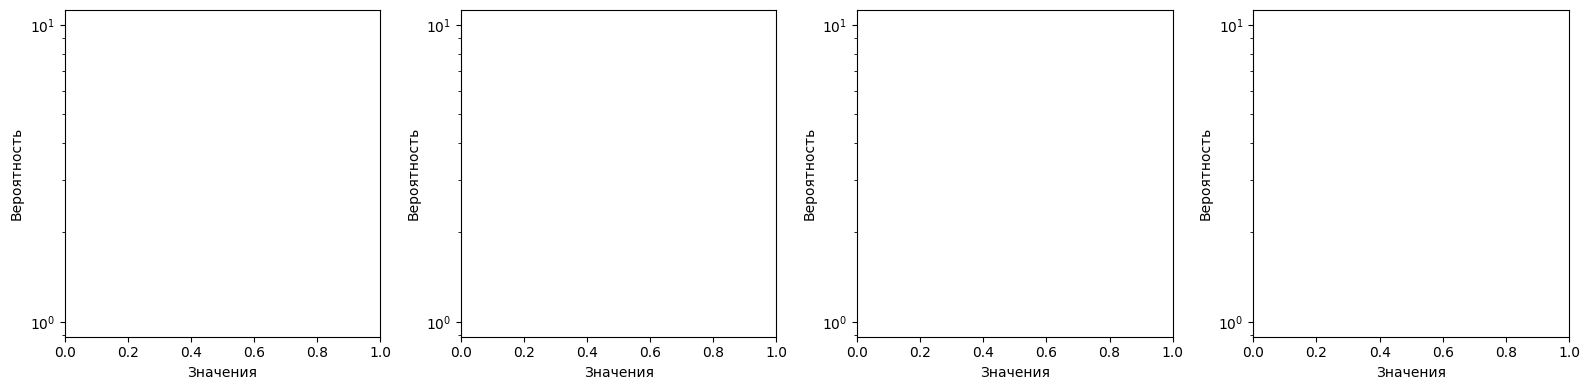

In [432]:
plt.figure(figsize=(16, 4))

for i in range(4):
    values, probs = dirichlet_processes(base_distibution=sps.norm, alpha=1)
    plt.subplot(1, 4, i + 1)
    for k in range(len(values)):
        plt.plot([values[k]] * 2, [0, probs[k]], lw=3)
    plt.xlabel("Значения")
    plt.ylabel("Вероятность")
    plt.yscale("log")
plt.tight_layout()

Повторите процедуру для $\alpha=10$ и $\alpha=0.1$.

Сделайте выводы.

__________________
### Задача 4.

Пусть выборка $X_1, ..., X_n$ имеет распределение смеси с неизвестным количеством компонент. Данные поступают последовательно, причем постепенно могут появляться новые кластеры, а старые &mdash; исчезать. Это означает, что мы не можем один раз по всей выборке определить оптимальное количество кластеров на основе какого-либо функционала. 

Такая задача может иметь смысл, например, для новостных агрегаторов, блог-платформ, социальных сетей. Мы можем получить векторное представление объектов (тексты статей, видеоролики), и далее для них решать задачу кластеризации. Но периодически могут появляться новые группы новостей, новые тренды, которые хотелось бы уметь автоматически выделять в отдельный кластер. В то же время, кластеры для устаревших новостей или трендов хотелось бы исключать. Возникает потребность в модели кластеризации, в которой можно автоматически добавлять новые кластеры, периодически обновляться на новых данных, а также "на лету" добавлять новые кластеры и удалять старые.

Определим модель следующим образом
* $\theta_1, \theta_2, ... \sim G_0$ &mdash; параметры каждого кластера, имеющие некоторое распределение $G_0$, являющееся базовым распределением в процессе stick-breaking;
* $V_1, V_2, ... \sim Beta(1, \alpha)$ &mdash; параметры доли отламываемой палки в процессе stick-breaking;
* $\pi_k = V_k \prod\limits_{j=1}^{k-1} (1-V_j)$ &mdash; параметры вероятностей кластеров;
* $Y_1, ..., Y_n$ &mdash; номера кластеров в виде one-hot векторов, то есть $Y_i = (Y_{ik})_{k=1}^\infty$, где $Y_{ik}\in\{0, 1\}$ и $\mathsf{P}(Y_{ik} = 1\ |\ \pi) = \pi_k$;
* $X_1, ..., X_n$ &mdash; выборка, в которой условное распределение $(X_i\:|\:Y_{ik}=1,\theta=t)$ описывается плотностью $p_{t_k}(x)$.

Совместное распределение всех величин в такой модели имеет вид
$$p(x, y, v, t) = \overbrace{\left[   \prod_{k=1}^{\infty} g_0(t_k) \rho_{\alpha}(v_k)   \right]}^{\text{\textcolor{green}{выбор параметров кластеров}}}   \prod_{i=1}^n   \prod_{k=1}^{\infty}   \left[    \overbrace{v_k \prod_{j=1}^{k-1}(1-v_j)}^{\text{\textcolor{green}{вер-ть кластера}}}  \cdot p_{t_k}(x_i)    \right]^{y_{ik}},$$
где $g_0$ &mdash; плотность распределения $G_0$, а $\rho_{\alpha}$ &mdash; плотность распределения $Beta(1, \alpha)$. Формула отличается от формулы совместного распределения простой смеси тем, что в данном случае параметры кластера случайны, и самих кластеров бесконечно.

Рассмотрим вариационное семейство, в котором наборы $(\theta_k)_{k=1}^\infty, (V_k)_{k=1}^\infty, (Y_i)_{i=1}^n$ независимы, причем распределение каждого из этих наборов произвольное.

**1.** Выполните шаг для обновления распределения $(Y_i)_{i=1}^n$. На основе полученного распределения предложите условия, при которых
* можно исключить все кластеры с номерами больше $K$,
* можно исключить некоторые кластеры с номерами меньше $K$.

**2.** Выполните шаг для обновления распределения $(V_k)_{k=1}^\infty$. Проинтерпретируйте параметры полученного распределения. На основе полученного распределения предложите условие, при котором стоит добавить новые кластеры.

**3.** Выпишите шаг для обновления распределения $(\theta_k)_{k=1}^\infty$ 
* в общем случае формулой в виде пропорциональности;
* в случае если $p_{t_k}(x)$ &mdash; плотность распределения $\mathcal{N}(a_k, \Sigma^2_k)$ и $G_0$ &mdash; неинформативное, а в вариационном семестве для $(\theta_k)_{k=1}^\infty$ рассматривается вырожденное распределение (т.е. нужно найти моду, см. сведение VI к EM).

*Подсказка.* Достаточно свести второй случай к уже решенной ранее задаче и выписать ответ.

**4.** Распишите ELBO.

**5.** Вычислите все математические ожидания по вариационным распределениям $(V_k)_{k=1}^\infty, (Y_i)_{i=1}^n$.

---
© 2025 команда <a href="https://thetahat.ru/">ThetaHat</a> для DS-потока